# 🧠 Analyzer: Análisis Exploratorio y Sistemático de Vulnerabilidades

Este notebook implementa la lógica principal del **Analyzer**, tomando como entrada los datos consolidados generados por el Miner (`vulnerabilities_dataset.csv`).

**Objetivos de la actividad:**
1. Caracterizar las vulnerabilidades en términos de tipo, frecuencia y severidad.
2. Analizar su distribución entre repositorios.
3. Identificar patrones relevantes en los resultados.
4. Proponer métricas o enfoques adicionales (Ej. *Risk Score*).

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
# Asegúrate de haber ejecutado `uv run python main.py analyze` previamente
dataset_path = '../data/results/vulnerabilities_dataset.csv'

try:
    df = pd.read_csv(dataset_path)
    print(f"✅ Dataset cargado exitosamente con {len(df)} hallazgos totales.")
    display(df.head())
except FileNotFoundError:
    print("❌ No se encontró el dataset. Por favor, ejecuta en tu terminal: uv run python main.py analyze")

✅ Dataset cargado exitosamente con 658 hallazgos totales.


,repo,type,id,severity,category,package
0,dataset-viewer,Dependency,GHSA-39mp-8hj3-5c49,HIGH,CWE-36,gradio
1,dataset-viewer,Dependency,GHSA-wp53-j4wj-2cfg,HIGH,CWE-22,python-multipart
2,dataset-viewer,Dependency,GHSA-8jw3-6x8j-v96g,MEDIUM,CWE-434,gradio
3,dataset-viewer,Dependency,GHSA-rvgh-pr46-x7gg,HIGH,CWE-1333,gradio
4,dataset-viewer,Dependency,GHSA-wj6h-64fc-37mp,HIGH,CWE-203,ecdsa


--- Distribución por Tipo de Análisis ---


type
Dependency         648
Static Analysis     10
Name: count, dtype: int64

/tmp/ipykernel_1386/2820279622.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='severity', order=orden_presente, palette='Reds_r')


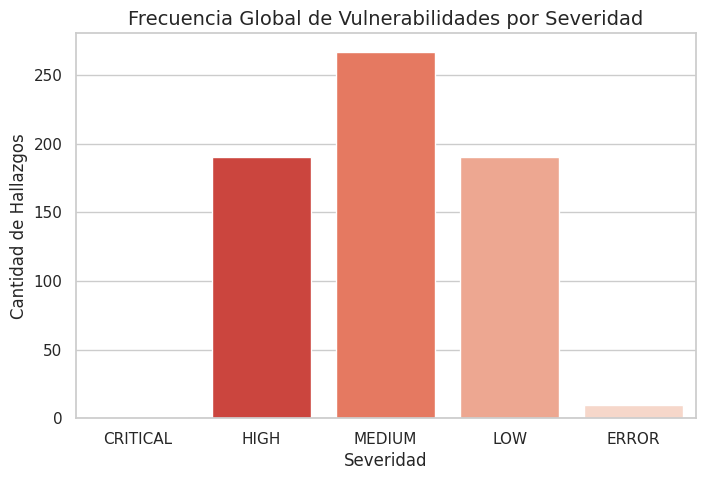

In [9]:
# 2.1 Distribución de tipos (Dependencias vs Código Fuente estático)
tipo_counts = df['type'].value_counts()
print("--- Distribución por Tipo de Análisis ---")
display(tipo_counts)

# 2.2 Frecuencia General por Severidad
plt.figure(figsize=(8, 5))
orden_severidad = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW', 'ERROR', 'UNKNOWN']
# Filtrar orden a solo las severidades presentes en nuestros datos
orden_presente = [s for s in orden_severidad if s in df['severity'].unique()]

sns.countplot(data=df, x='severity', order=orden_presente, palette='Reds_r')
plt.title('Frecuencia Global de Vulnerabilidades por Severidad', fontsize=14)
plt.ylabel('Cantidad de Hallazgos')
plt.xlabel('Severidad')
plt.show()

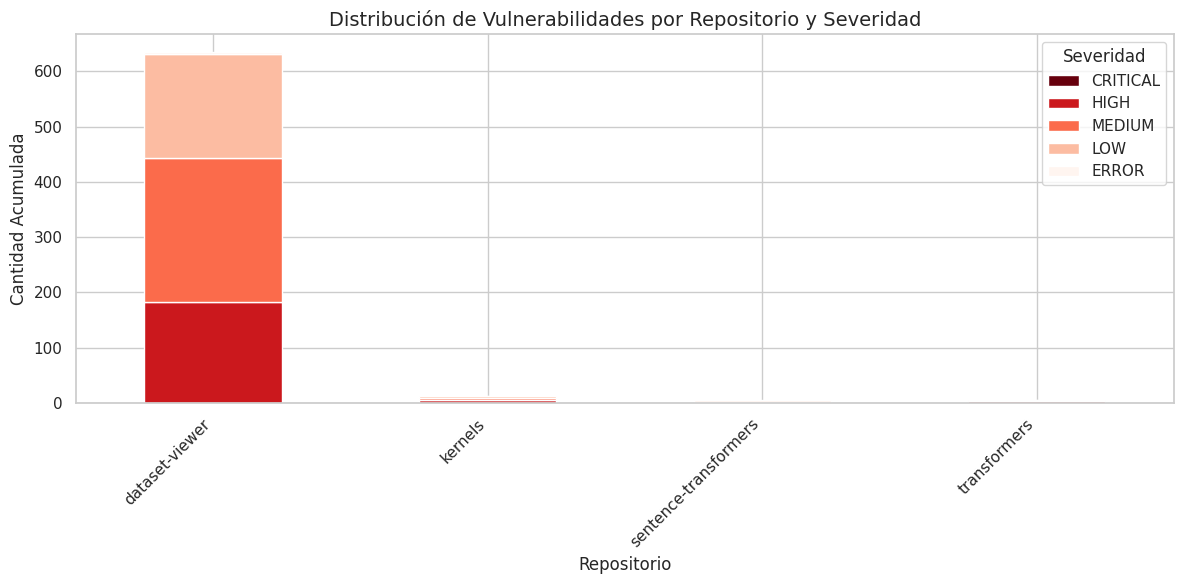

In [10]:
# Crear una tabla cruzada de Repositorio vs Severidad
repo_sev = pd.crosstab(df['repo'], df['severity'])[orden_presente]

repo_sev.plot(kind='bar', stacked=True, colormap='Reds_r', figsize=(12, 6))
plt.title('Distribución de Vulnerabilidades por Repositorio y Severidad', fontsize=14)
plt.ylabel('Cantidad Acumulada')
plt.xlabel('Repositorio')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severidad')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1386/1623806450.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pkgs.values, y=top_pkgs.index, ax=axes[0], palette='magma')
/tmp/ipykernel_1386/1623806450.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1], palette='viridis')


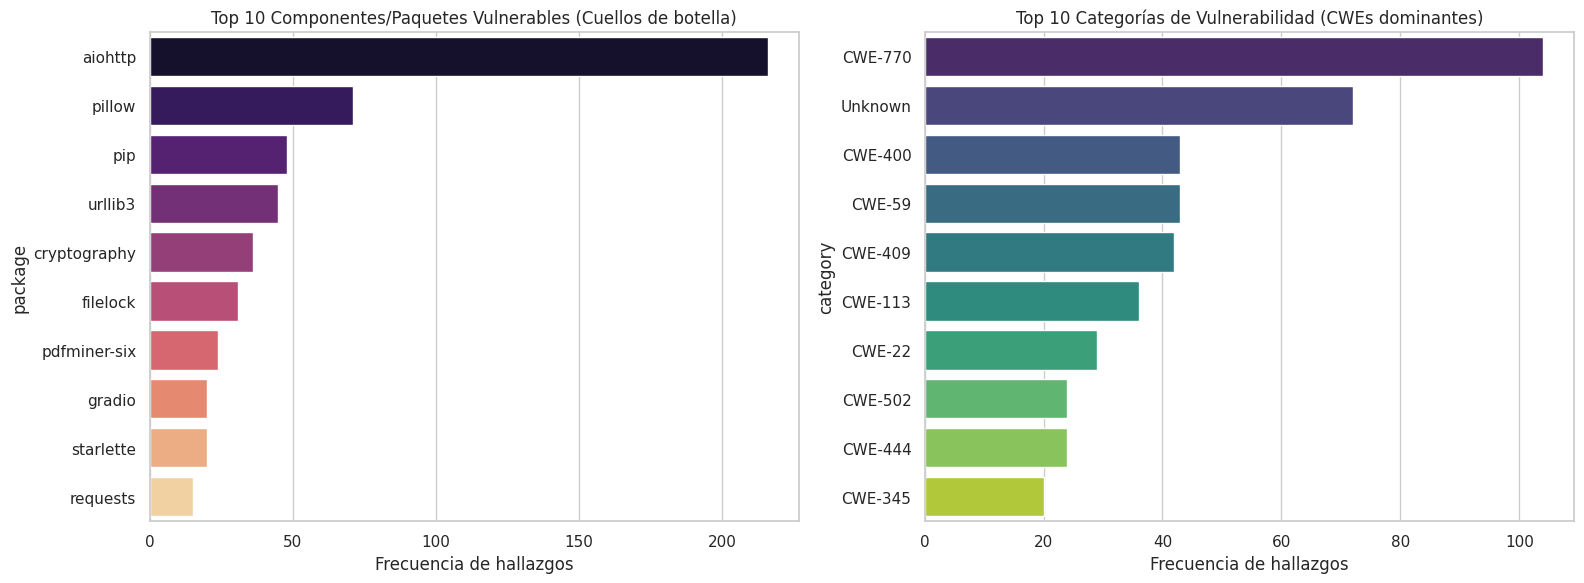

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Patrón 1: Top 10 Paquetes más Vulnerables (Concentración de riesgo)
top_pkgs = df['package'].value_counts().head(10)
sns.barplot(x=top_pkgs.values, y=top_pkgs.index, ax=axes[0], palette='magma')
axes[0].set_title(
    'Top 10 Componentes/Paquetes Vulnerables (Cuellos de botella)')
axes[0].set_xlabel('Frecuencia de hallazgos')

# Patrón 2: Top 10 Categorías de Debilidades (CWEs)
top_cats = df['category'].value_counts().head(10)
sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Categorías de Vulnerabilidad (CWEs dominantes)')
axes[1].set_xlabel('Frecuencia de hallazgos')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1386/2550323179.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_by_repo.values, y=risk_by_repo.index, palette='flare')


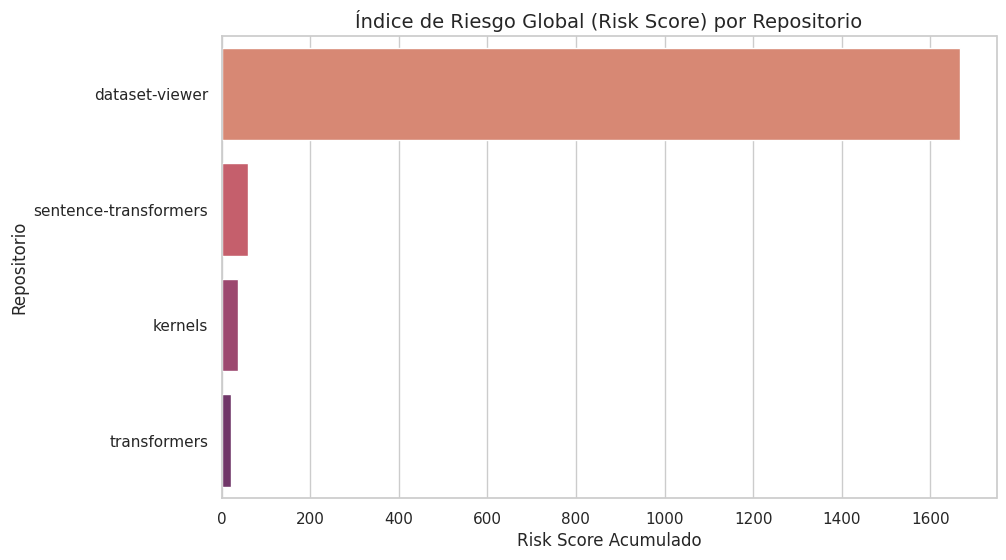

--- Top Repositorios ordenados por Nivel de Riesgo ---


,risk_score
repo,
dataset-viewer,1666
sentence-transformers,60
kernels,37
transformers,21


In [12]:
pesos_severidad = {
    'CRITICAL': 10,
    'ERROR': 10,
    'HIGH': 5,
    'MEDIUM': 2,
    'LOW': 1,
    'UNKNOWN': 1
}

df['risk_score'] = df['severity'].map(pesos_severidad).fillna(0)

# Calcular Risk Score acumulado por Repositorio
risk_by_repo = df.groupby(
    'repo')['risk_score'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=risk_by_repo.values, y=risk_by_repo.index, palette='flare')
plt.title('Índice de Riesgo Global (Risk Score) por Repositorio', fontsize=14)
plt.xlabel('Risk Score Acumulado')
plt.ylabel('Repositorio')
plt.show()

print("--- Top Repositorios ordenados por Nivel de Riesgo ---")
display(risk_by_repo.to_frame())

# Conclusión del análisis de riesgos en los repositorios

Revisando los datos consolidados en `vulnerabilities_dataset.csv`, armé este ranking de riesgo de mayor a menor gravedad:

### 1. dataset-viewer: El más crítico
Es el repositorio más problemático de todos y el que concentra casi todas las vulnerabilidades.
* **Dependencias:** Tiene muchos fallos graves en librerías clave como `gradio`, `starlette`, `aiohttp`, `pdfminer-six` y `cryptography`.
* **Código:** Encontramos riesgos de SSRF y partes donde se guarda información confidencial en texto plano.
* **Impacto:** Al estar expuesto a la web y tener estos fallos directos en el código, es el que necesita arreglos más urgentes.

### 2. sentence-transformers: Problemas graves al descomprimir
Aunque no tiene una lista enorme de dependencias desactualizadas, el código en sí tiene fallos importantes.
* **Código:** Hay 6 errores críticos al extraer archivos comprimidos (Tar Slip) que permiten sobrescribir archivos del sistema.
* **Impacto:** Como en Machine Learning se descargan y extraen modelos todo el tiempo, esto es muy peligroso. Alguien podría lograr ejecutar código malicioso simplemente colando un archivo `.tar` manipulado.

### 3. kernels: Falta de mantenimiento
Tiene un nivel de riesgo moderado-alto, más que nada concentrado en las herramientas que usan para desarrollar.
* **Dependencias:** Hay vulnerabilidades en librerías como `pillow`, `gitpython`, `black` y `pytest`.
* **Impacto:** Aunque es más difícil que alguien ataque por acá, deja claro que falta mantenimiento y actualizar cosas básicas en el entorno.

### 4. transformers: Riesgo en GitHub Actions
Lo llamativo de este repositorio es que los problemas no están en el código, sino en cómo se despliega.
* **Pipeline:** Hay vulnerabilidades en las acciones de GitHub, puntualmente en `actions/download-artifact` y `pypa/gh-action-pypi-publish`.
* **Impacto:** El riesgo acá está en el proceso de compilación y publicación. Alguien podría comprometer los paquetes mientras se están construyendo.

> **Resumen de lo que hay que hacer:**
> Cada repositorio tiene un tipo de problema muy distinto:
> * **dataset-viewer:** Hay que actualizar las dependencias y corregir el código ya mismo por su exposición a la web.
> * **sentence-transformers:** Tienen que arreglar urgentemente la forma en que descomprimen archivos.
> * **transformers:** Nos recuerda que asegurar los flujos de CI/CD es igual de importante que asegurar el código.